In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import seaborn as sns
%matplotlib qt

import tools.particle_swarm_optimization as pso
import tools.particle_swarm_optimization_plot as pso_plt
import tools.peristimulus_time_histogram as psth

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [52]:
# data_path = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20250629003512/'

# activity = psth.get_data(data_path, 4000, 1000, '2/3a', 'exc')
# print(activity)
# pso.save_result(data_path, 0, 0, activity)


folder_path = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/'


pso.generate_next_iteration(folder_path, 0, 2, 2)

***********************
[0.         0.         2.48537446]
***********************
[0.         0.         2.48537446]
***************
[0.06443563 0.03157836]
[0. 0.]
[[0. 0.]]
[[0. 0.]]
[[-0.0081061   0.00909961]]
[0.         1.         3.24329159]
***************
[0.02902684 0.0176434 ]
[0. 0.]
[[0. 0.]]
[[0.00809802 0.00197003]]
[[0.00517724 0.00218018]]


In [146]:
## Raster plot y firing rate
## por simulación

from utils import helpers
import scipy.stats as stats

data_path = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 5 mcc 4000 ms/'

populations = ['L23E', 'L23I', 'L4E', 'L4I', 'L5E', 'L5I', 'L6E', 'L6I']
names = ['CMC V1 ( l )', 'CMC V1 ( \\ )', 'CMC V1 ( - )', 'CMC V1 ( / )', 'CMC V2']
#names = ['CMC V1 ( l )', 'CMC V1 ( \\ )', 'CMC V1 ( - )', 'CMC V1 ( / )']
#names = ['CMC V1 ( l )']
#names = ['']

all_pops = []

for i in names:
    all_pops += list(map(lambda pop: f"{pop}",populations))

t_sim = 4000

if False:
    firing_rates_interval = np.array([0, t_sim])

    print('Interval to compute firing rates: {} ms'.format(firing_rates_interval))
    helpers.firing_rates(
        data_path,
        'spike_recorder',
        0,
        t_sim)
    helpers.boxplot(data_path, all_pops, 'firing_rate_',  False, True, names)

if False:
    id_sim = data_path.split("/")[-1]
    helpers.plot_raster(
        data_path,
        'spike_recorder',
        0,
        t_sim,
        0.2,
        all_pops,
        id_sim)


######################## test estadistico

if True:

    data_path1 = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 4 mcc 4000 ms/'
    data_path2 = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 5 mcc 4000 ms/'

    pval_1, pval_2 = [], []

    for i in range(8):
        g1 = np.loadtxt(os.path.join(data_path1, ('rate' + str(i) + '.dat')))
        g2 = np.loadtxt(os.path.join(data_path2, ('rate' + str(i) + '.dat')))
        g3 = np.loadtxt(os.path.join(data_path2, ('rate' + str(i+32) + '.dat')))

        n, p = stats.mannwhitneyu(g1,g2)
        pval_1.append(p)

        n, p = stats.mannwhitneyu(g1,g3)
        pval_2.append(p)

    # Redondear a 2 decimales
    pval_1r = [round(valor, 4) for valor in pval_1]  
    pval_2r = [round(valor, 4) for valor in pval_2]  
    print(pval_1r)
    print(pval_2r)
        

[0.0, 0.8884, 0.0, 0.0005, 0.0, 0.818, 0.0, 0.0716]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.1253, 0.0, 0.654]


Text(50.722222222222214, 0.5, 'To')

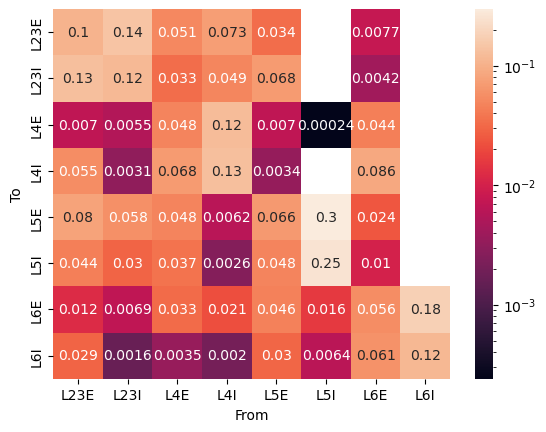

In [6]:


prob = np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0854, 0.1647, 0.0043, 0.,     0.1077, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )*0.8

ax_lab = ['L23E', 'L23I', 'L4E', 'L4I', 'L5E', 'L5I', 'L6E', 'L6I']

glue = sns.load_dataset("glue").pivot(index="Model", columns="Task", values="Score")
sns.heatmap(prob, annot=True, norm=LogNorm(), xticklabels=ax_lab, yticklabels=ax_lab)
plt.xlabel('From')
plt.ylabel('To')



In [45]:
data_path = '/home/samuel/Work/CENIA/canonical_microcircuits/results/potjans_diesmann/20241217170621'
folder_path = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/'

pso.modify_performance(folder_path)
#activity = psth.get_data(data_path, 1500, 500, '2/3a', 'exc')

#pso.save_imposed_result(folder_path, 0, 0, activity)

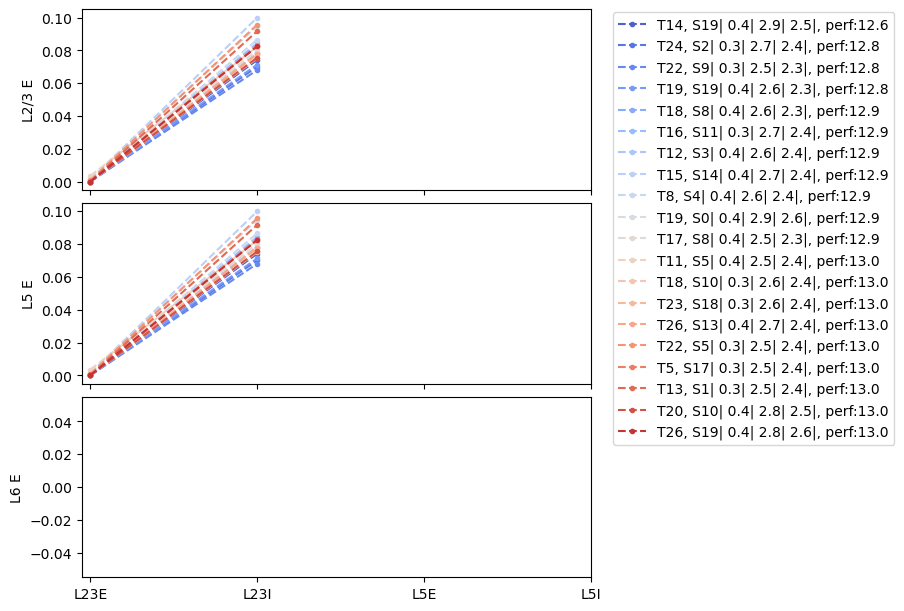

In [48]:
# plot params PSO
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/')

suj = 7
pso_plt.plot_best_params(folder_path, 'all')
#pso_plt.plot_best_params(folder_path, 'sub')

#pso.plot_params(folder_path, 59,-1)
#pso.plot_performance(folder_path, -1, -1, -1)

#pso_plt.plot_performance(folder_path, -1, suj, -1)
#pso_plt.plot_params(folder_path, -1, suj)

#pso.plot_activity(folder_path, -1, -1, -10)
plt.show()

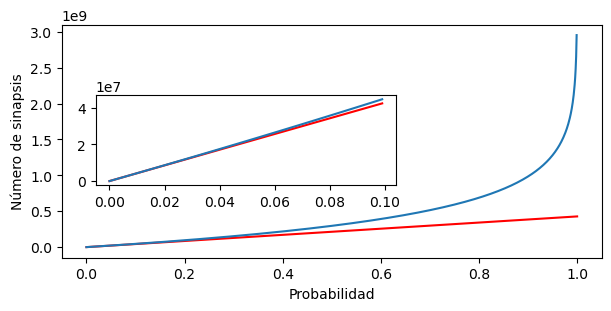

In [195]:
# plot del número de sinapsis
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
prods = np.array([10, 100, 1000, 1000])

ng = 20683
prod = ng*ng
prob = np.linspace(0,1,1000)
rs = np.log(1. - prob) / np.log((prod - 1.) / prod)
ws = prob*prod

fig, ax = plt.subplots(1, layout='constrained', figsize=(6,3), sharex=True,sharey=True)

ax.plot(prob, ws,'r')
ax.plot(prob, rs)

left, bottom, width, height = 0.15, 0.4, 0.5, 0.3
ax2 = fig.add_axes([left, bottom, width, height])
ax2.plot(prob[:100], ws[:100],'r')
ax2.plot(prob[:100], rs[:100])

ax.set_xlabel('Probabilidad')
ax.set_ylabel('Número de sinapsis')
plt.show()



Text(0.5, 0.98, 'Cantidad de sinapsis del promedio de los 20 mejores')

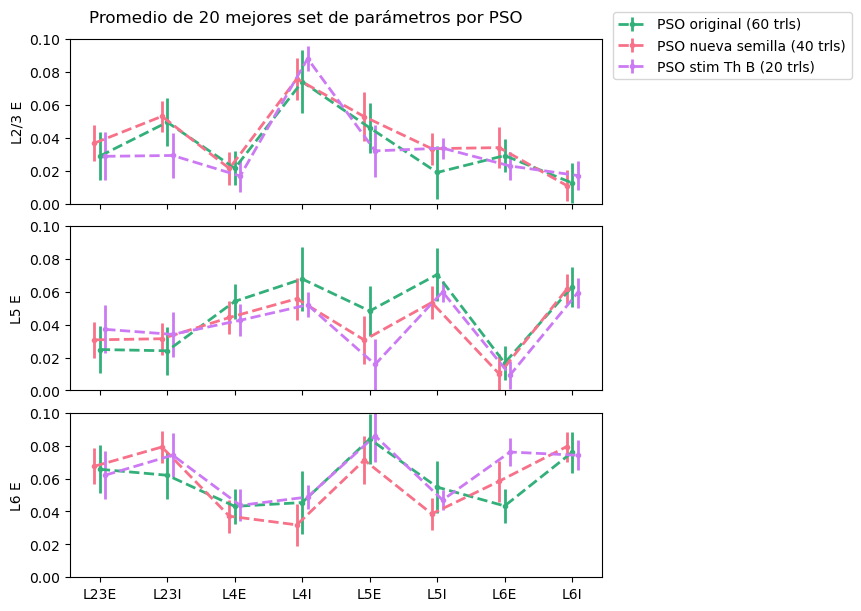

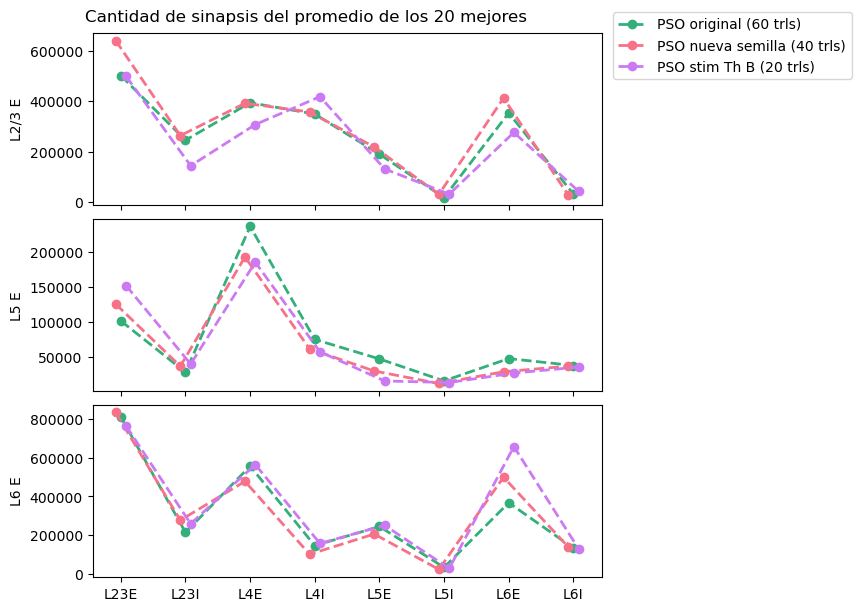

In [4]:
#print figura proimedios y número de sinapsis
folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

params = range(0, 8*3)
df = pd.read_csv(os.path.join(folder_path, 'test.csv'), header=None, names=params)
Df = df.values

clrs = sns.color_palette('husl', n_colors=5)  # a list of RGB tuples
labels =['PSO nueva semilla (40 trls)','PSO original (60 trls)','PSO stim Th B (20 trls)']

fig, ax = plt.subplots(3, layout='constrained', figsize=(6,6), sharex=True,sharey=True)
for i in [2,0,4]:
    l = (i-2)/25
    ax[0].errorbar(np.linspace(0+l,7+l,8), Df[i][0:8], Df[i+1][0:8],
        fmt='.--', lw=2, c=clrs[i])
    ax[1].errorbar(np.linspace(0+l,7+l,8), Df[i][8:16], Df[i+1][0:8],
        fmt='.--', lw=2, c=clrs[i])
    ax[2].errorbar(np.linspace(0+l,7+l,8), Df[i][16:24], Df[i+1][0:8],
        fmt='.--', lw=2, c=clrs[i], label=labels[int(i/2)])
ax[0].set_ylabel('L2/3 E')
ax[1].set_ylabel('L5 E')
ax[2].set_ylabel('L6 E')
ax[2].set_xticks(range(8),['L23E','L23I','L4E','L4I','L5E','L5I','L6E','L6I'])
ax[2].set_ylim([0, 0.1])
fig.legend(loc='upper left', bbox_to_anchor=(1.0,1),
    fancybox=True, shadow=False, ncol=1)
fig.suptitle('Promedio de 20 mejores set de parámetros por PSO')


popsize1 = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])
popsize2 = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])
prod = np.outer(popsize1, popsize2)

fig, ax = plt.subplots(3, layout='constrained', figsize=(6,6), sharex=True)
for i in [2,0,4]:
    l = (i-2)/25
    new_conn_probs = pso.new_conn_probs(Df[i])
    num_synapses = np.log(1. - new_conn_probs) / np.log((prod - 1.) / prod)
    ns = np.round((num_synapses *0.2 *0.2)).astype(int)

    ax[0].plot(np.linspace(0+l,7+l,8), ns[:,0], 'o--', lw=2, c=clrs[i])
    ax[1].plot(np.linspace(0+l,7+l,8), ns[:,4], 'o--', lw=2, c=clrs[i])
    ax[2].plot(np.linspace(0+l,7+l,8), ns[:,6], 'o--', lw=2, c=clrs[i], 
        label=labels[int(i/2)])
ax[0].set_ylabel('L2/3 E')
ax[1].set_ylabel('L5 E')
ax[2].set_ylabel('L6 E')
ax[2].set_xticks(range(8),['L23E','L23I','L4E','L4I','L5E','L5I','L6E','L6I'])
#ax[2].set_ylim([0, 0.1])
fig.legend(loc='upper left', bbox_to_anchor=(1.0,1),
    fancybox=True, shadow=False, ncol=1)
fig.suptitle('Cantidad de sinapsis del promedio de los 20 mejores')



In [4]:
# plot params 2D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plot1, plot2, plot3 = True, True, True
n_part, n_trl = 15, 57

folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/')

# add columns names
cols = np.array(['trials', 'subjects'])
params = range(3)
names = np.concatenate((cols, params), axis=None)
df = pd.read_csv(os.path.join(folder_path, 'swarm.csv'), header=None, names=names)

cols = np.array(['trials', 'subjects'])
params = range(8)
names = np.concatenate((cols, params), axis=None)
df2 = pd.read_csv(os.path.join(folder_path, 'results.csv'), header=None, names=names)
best = df2.sort_values('7').values
print(best[0])

X = df['0'].values
Y = df['1'].values
Z = df2['7'].values
Z[Z>4]=4

#################################################
if plot1:
    fig = plt.figure(layout='constrained', figsize=(5,8))
    ax = fig.add_subplot(projection='3d') #
    ax.scatter(X, Y, Z, marker='.', c=np.log(Z))
    ax.set_zlim(0.8, 2.3)
    # Set the azimuth and elevation angles
    ax.view_init(azim=235, elev=15)
    ax.set_xlabel('L2/3E')
    ax.set_ylabel('L2/3I')
    ax.set_zlabel('Desempeño')
    fig.suptitle('Desempeño en función de la conectividad lateral supragranular')

#################################################
clrs = sns.color_palette('husl', n_colors=n_part)
if plot2:

    fig, ax = plt.subplots(1, 1, layout='constrained', figsize=(6.7, 6.2), sharey=True) #figsize=(4.7, 4)
    ax.scatter(X, Y,  marker='.', c=clrs*n_trl)
    for i in range(n_part):
        ax.scatter(X[i], Y[i],  marker='o', c=clrs[i], label='p: '+str(i))
    ax.set_ylabel('L2/3 I')
    ax.set_xlabel('L2/3 E')
    lin = [0,0.025,0.05,0.075,0.1]
    ax.set_xticks(lin, lin)
    ax.set_yticks(lin, lin)
    x1, x2 = ax.get_xlim()
    y1, y2 = ax.get_ylim()

    L = 0.003
    ax.set_xlim([0-L, 0.1+L])
    ax.set_ylim([0-L, 0.1+L])

    ax.grid(visible=True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.0,1),
                fancybox=True, shadow=False, ncol=1)
    fig.suptitle('Optimización de Parámetros con PSO\nConectividad Lateral L2/3')
    plt.show()

#################################################
if plot3:
    ee, ei = [], []
    fig, ax = plt.subplots(1, layout='constrained', figsize=(7,4), sharey=True)
    for i, suj in enumerate(best):
        suj_suj = df[(df['trials']==suj[0]) & (df['subjects']==suj[1])].values[0]
        ee.append(suj_suj[2])
        ei.append(suj_suj[3])
        ax.scatter(suj_suj[2], suj_suj[3], marker='o', s=100, c=clrs[i],
            label='trl '+str(int(suj[0]))+
                ', suj '+str(int(suj[1]))+
                ', perf '+str(round(suj[9],3)))
        if i == 14:
            break

    # Create linear regression object
    # regr = LinearRegression()

    # ee = np.array(ee)
    # ei = np.array(ei)
    # regr.fit(ee.reshape(n_part,1), ei.reshape(n_part,1))
    # eiy = regr.predict(np.array([[-0.1],[0.1]]))

    ax.set_ylabel('L2/3 I')
    ax.set_xlabel('L2/3 E')
    lin = [0,0.025,0.05,0.075,0.1]
    ax.set_xticks(lin, lin)
    ax.set_yticks(lin, lin)

    bottom, top = plt.ylim()  # return the current ylim
    a1, a2 = plt.xlim()  # return the current ylim
    #ax.plot([[-0.1],[0.1]],eiy,'r')

    plt.ylim([bottom, top])
    plt.xlim([a1, a2])
    ax.grid(visible=True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.0,1),
                fancybox=True, shadow=False, ncol=1)
    fig.suptitle('Mejores 25 set de parámetros')

    # Ahora puedo obtener el coeficiente b_1
    print(u'Coeficiente beta1: ', regr.coef_[0])
    
    # Podemos predecir usando el modelo
    y_pred = regr.predict(ee.reshape(n_part,1))
    
    # Por último, calculamos el error cuadrático medio y el estadístico R^2
    print(u'Error cuadrático medio: %.2f' % mean_squared_error(ei.reshape(n_part,1), y_pred))
    print(u'Estadístico R_2: %.2f' % r2_score(ei.reshape(10,1), y_pred))
    plt.show()

[23.         14.          0.38098922  2.82889329  1.97456849  0.92733163
  0.38098922  0.29130687  0.04115457  0.71345066]


NameError: name 'regr' is not defined

In [6]:
## intento de merge de las bases de datos

merge_result = False
if merge_result: 
    # Results
    cols = np.array(['trials', 'subjects'])
    params = range(5)
    names = np.concatenate((cols, params), axis=None)

    df0 = pd.read_csv(os.path.join(folder_path, 'results0.csv'), header=None, names=names)
    df1 = pd.read_csv(os.path.join(folder_path, 'results1.csv'), header=None, names=names)
    m = df0.columns.to_list()

    trial = df0['trials'].unique()
    subject = df0['subjects'].unique()

    for j, trl in enumerate(trial):
        for i, suj in enumerate(subject):

            activity = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
            n_df = pd.DataFrame([np.concatenate(([trl, suj], activity), axis=None)])

            n_df.to_csv(os.path.join(folder_path, 'results.csv'), mode='a', index=False, header=False)

        for i, suj in enumerate(subject):

            activity = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
            n_df = pd.DataFrame([np.concatenate(([trl, suj+10], activity), axis=None)])

            n_df.to_csv(os.path.join(folder_path, 'results.csv'), mode='a', index=False, header=False)


# Swarm
cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df0 = pd.read_csv(os.path.join(folder_path, 'swarm0.csv'), header=None, names=names)
df1 = pd.read_csv(os.path.join(folder_path, 'swarm1.csv'), header=None, names=names)
m = df0.columns.to_list()

trial = df0['trials'].unique()
subject = df0['subjects'].unique()

for j, trl in enumerate(trial):
    for i, suj in enumerate(subject):

        params = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm.csv'), mode='a', index=False, header=False)

    for i, suj in enumerate(subject):

        params = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj+10], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm.csv'), mode='a', index=False, header=False)


FileNotFoundError: [Errno 2] No existe el fichero o el directorio: '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/swarm0.csv'

Variance explained by each principal component: [2.24370724e-01 1.91251125e-01 1.48740917e-01 1.21393815e-01
 1.11319585e-01 7.97568904e-02 5.96120628e-02 4.16070609e-02
 2.19478216e-02 1.80523833e-33]
Variance explained by each principal component: 1.0


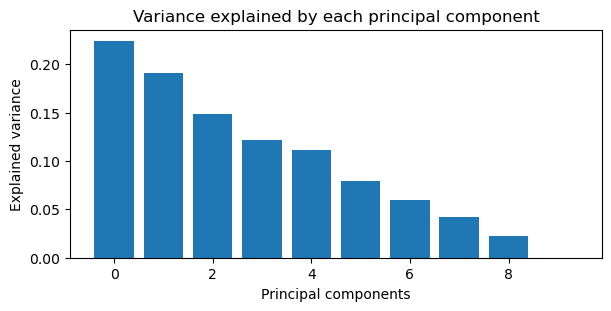

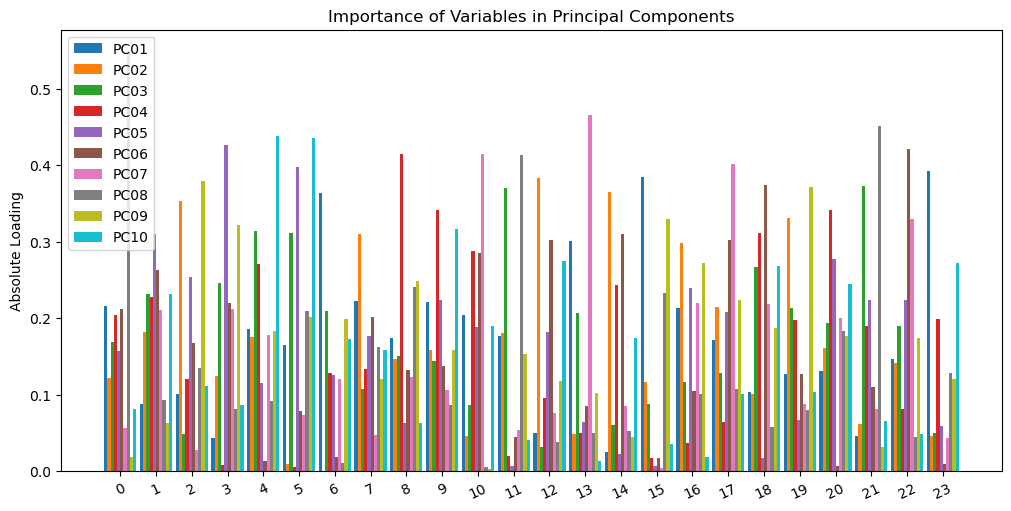

In [137]:
# PCA cluster
# Separate features and group information
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df = pd.read_csv(os.path.join(folder_path, 'swarm.csv'), header=None, names=names)
pca_metrics = df.columns.to_list()
features = df[pca_metrics[2:]]
group_info = df[['trials', 'subjects']]

# Standardize the data (necessary for a good PCA)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Principal component analysis (PCA)
n_comp = 10
pca = PCA(n_components=n_comp)
principal_components = pca.fit_transform(scaled_features)

comp_names = ['PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC06', 'PC07', 'PC08', 'PC09','PC10',
            'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19','PC20',
            'PC21', 'PC22', 'PC23', 'PC24']

# Visualize the variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print("Variance explained by each principal component:", explained_variance)
print("Variance explained by each principal component:", np.sum(explained_variance))

# Plot the variance explained by each principal component
fig, ax = plt.subplots(layout='constrained', figsize=(6, 3))
bars = plt.bar(range(len(explained_variance)), explained_variance, align='center')
#plt.xticks(range(len(explained_variance)), comp_names[:len(explained_variance)])
plt.xlabel('Principal components')
plt.ylabel('Explained variance')
plt.title('Variance explained by each principal component')
plt.show()

# A new DataFrame is generated with the PCA principal components
loadings = pca.components_.T
pca_df = pd.DataFrame(loadings, index=features.columns, columns=comp_names[:len(explained_variance)])

# Visualize the importance of the variables in the principal components
fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))
bar_l, x_pos = 0.9/n_comp, np.arange(0,len(pca_metrics[2:]))
for i in range(n_comp):
    plt.bar(x_pos-((bar_l/2)*(n_comp-1))+i*bar_l, np.abs(pca_df[comp_names[i]]), width=bar_l, label=comp_names[i])

plt.xticks(range(len(pca_metrics[2:])), pca_df.index, rotation=25)
plt.ylabel('Absolute Loading')
plt.title('Importance of Variables in Principal Components')
plt.legend()
plt.show()

/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119210524
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119211000
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119211423
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119211850
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119212320
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119233627
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119234057
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119234515
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/CRF_v1_05hz/20250119234943
/home/samuelmr/Documentos/NEST/canoni

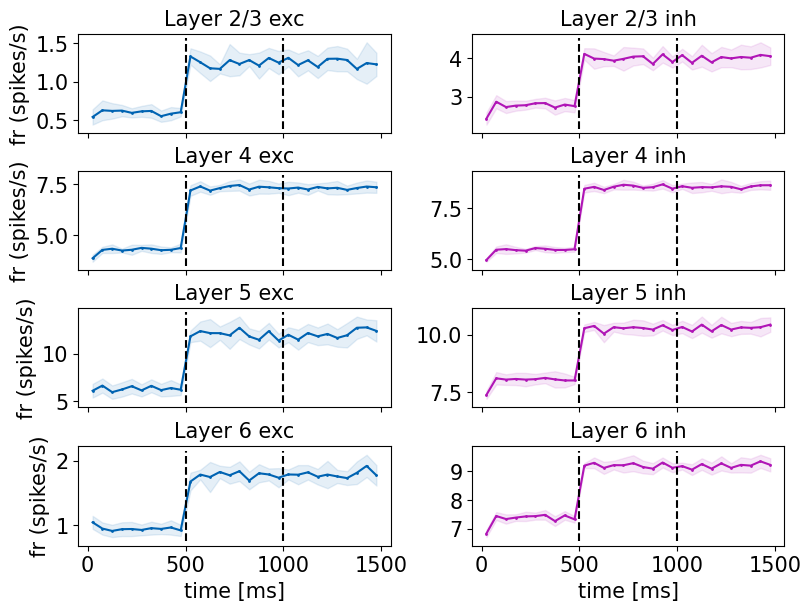

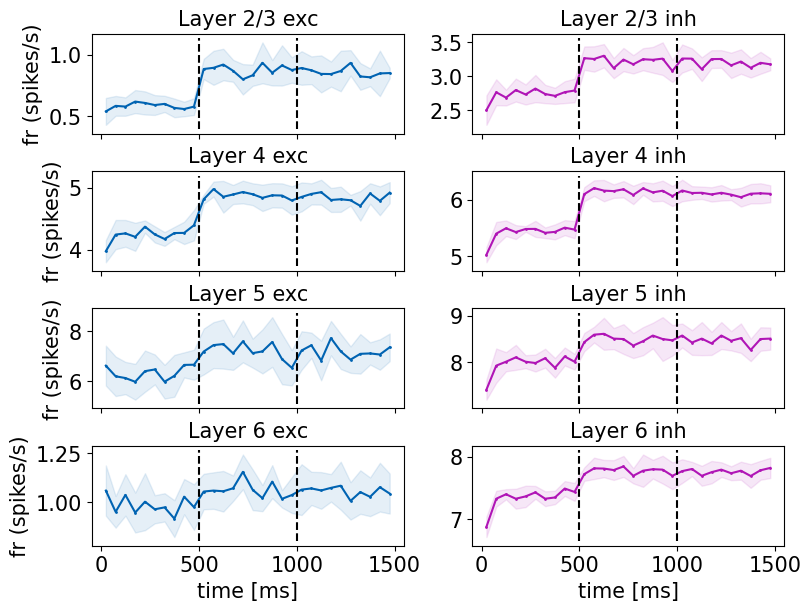

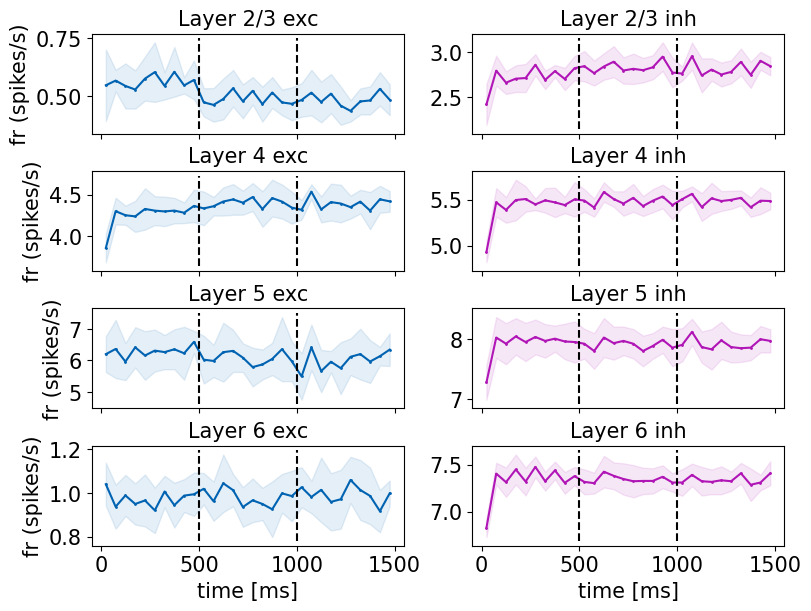

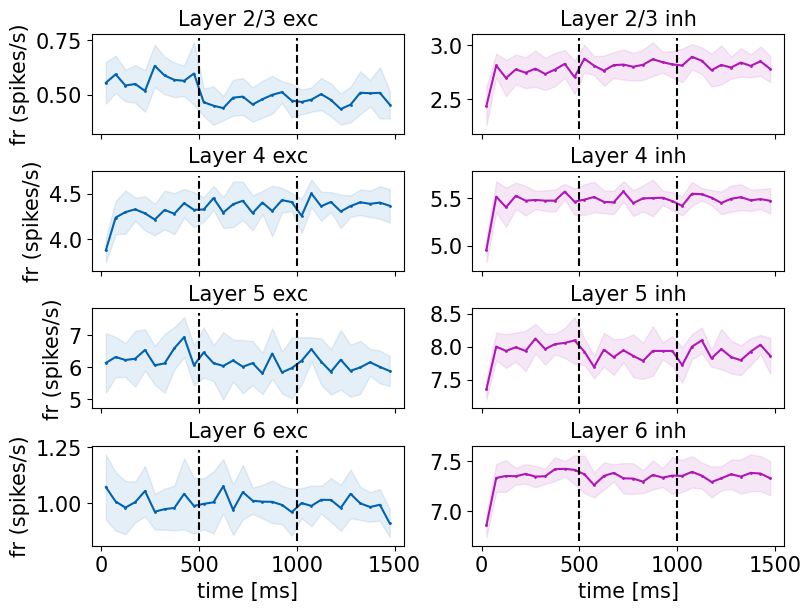

In [158]:
# PSTH nuevos
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/CRF_v1_05hz')
#folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_4'

#fp = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20250112230001/'
l_bin = 50
t_sim = 1500

#psth.PSTH_data(fp, 0.2, 1500, l_bin)
#psth.PSTH_plot_tog(fp, 1500, l_bin)

psth.PSTH_folders_data(folder_path, 0.2, t_sim, l_bin) 

psth.PSTH_figure(folder_path, t_sim, l_bin, 0)
psth.PSTH_figure(folder_path, t_sim, l_bin, 1)
psth.PSTH_figure(folder_path, t_sim, l_bin, 2)
psth.PSTH_figure(folder_path, t_sim, l_bin, 3)
#psth.PSTH_figure(folder_path, t_sim, l_bin, 4)
#psth.PSTH_figure(folder_path, t_sim, l_bin, 5)
#psth.PSTH_plot_tog(folder_path, t_sim, l_bin)

#psth.PSTH_plot(folder_path, 1500, l_bin)



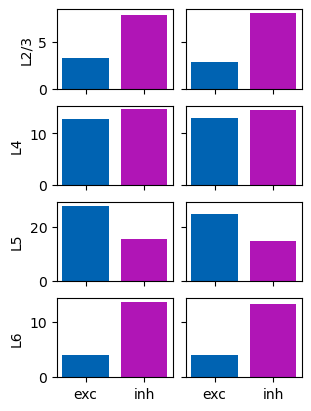

In [478]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result2_3'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(4,2,layout='constrained', figsize=(3,4), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']

for j,jj in enumerate(range(0,16,4)):

    ax[j,0].bar(0, subset[jj,1],color='#0063B2')
    ax[j,0].bar(1, subset[jj+2,1],color='#b015b6')
    ax[j,0].set_ylabel(layer[j])

    ax[j,1].bar(0, subset[jj,2],color='#0063B2')
    ax[j,1].bar(1, subset[jj+2,2],color='#b015b6')

ax[1,0].set_xticks([0,1],['exc','inh'])


# plt.xlabel('Time (ms)')
# plt.ylabel('Firing rate (Hz)')
# plt.title('PSTH L5 exc')
# plt.show()

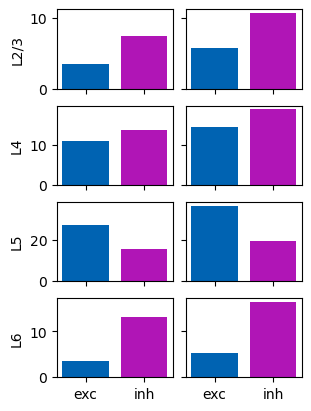

In [4]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_4'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(4,2,layout='constrained', figsize=(3,4), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']

for j,jj in enumerate(range(32,16+32,4)):

    ax[j,0].bar(0, subset[jj,1],color='#0063B2')
    ax[j,0].bar(1, subset[jj+2,1],color='#b015b6')
    ax[j,0].set_ylabel(layer[j])

    ax[j,1].bar(0, subset[jj,2],color='#0063B2')
    ax[j,1].bar(1, subset[jj+2,2],color='#b015b6')

ax[1,0].set_xticks([0,1],['exc','inh'])


# plt.xlabel('Time (ms)')
# plt.ylabel('Firing rate (Hz)')
# plt.title('PSTH L5 exc')
plt.show()